# Tier 1 Baseline Models

This notebook compares Tier 1 machine-learning references using the chronological datasets produced by the preparation phase.

The validation set is used for model and configuration selection. Test labels are loaded and their class counts are inspected for split integrity, but the test set is reserved from model selection and threshold selection.

Average Precision (AP) is the primary PR-based ranking metric. Precision, Recall, F1-score, and confusion matrices are reported at a fixed threshold of 0.5 as descriptive baseline metrics.

## 1. Data Handoff and Evaluation Protocol

### 1.1 Project Paths and Processed Inputs

The processed datasets generated during the data preparation phase are stored in the project's `data/processed/` directory.

The same directory structure will be used throughout the subsequent modeling phases.

In [1]:
# Import the libraries required for loading and inspecting the processed datasets.
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
# Resolve the project root whether Jupyter starts in the repository or notebooks/.
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "notebooks").is_dir() and (candidate / "data").is_dir()
    ),
    Path.cwd(),
)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Directory exists: {PROCESSED_DIR.exists()}")

Project root: /home/anderjcruz/projects/Bank-Fraud-Detection
Processed data directory: /home/anderjcruz/projects/Bank-Fraud-Detection/data/processed
Directory exists: True


#### Processed Dataset Loading

The processed training, validation, and test datasets are loaded from Parquet files generated by the preparation notebook. Both unscaled and RobustScaler-transformed features are loaded for the model families that need them.

In [3]:
# Load the original unscaled feature datasets.
X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_val = pd.read_parquet(PROCESSED_DIR / "X_val.parquet")
X_test = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")

# Load the RobustScaler-transformed feature datasets.
X_train_scaled = pd.read_parquet(PROCESSED_DIR / "X_train_scaled.parquet")
X_val_scaled = pd.read_parquet(PROCESSED_DIR / "X_val_scaled.parquet")
X_test_scaled = pd.read_parquet(PROCESSED_DIR / "X_test_scaled.parquet")

# Load the target datasets and convert them from DataFrames to Series.
y_train = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")["Class"]
y_val = pd.read_parquet(PROCESSED_DIR / "y_val.parquet")["Class"]
y_test = pd.read_parquet(PROCESSED_DIR / "y_test.parquet")["Class"]

# Display the dimensions of the loaded datasets.
print("Unscaled features:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\nScaled features:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

print("\nTarget:")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")

Unscaled features:
X_train: (199364, 32)
X_val:   (42721, 32)
X_test:  (42722, 32)

Scaled features:
X_train_scaled: (199364, 32)
X_val_scaled:   (42721, 32)
X_test_scaled:  (42722, 32)

Target:
y_train: (199364,)
y_val:   (42721,)
y_test:  (42722,)


### 1.2 Dataset Integrity

Before training the baseline models, the loaded datasets are checked for consistency with the data preparation phase.

The validation includes:

- Feature dimensionality
- Target class distribution
- Missing values
- Infinite values
- Feature consistency across splits

In [4]:
# Verify that all feature datasets contain the expected 32 modeling features.
print("Number of features:")
print(f"X_train: {X_train.shape[1]}")
print(f"X_val:   {X_val.shape[1]}")
print(f"X_test:  {X_test.shape[1]}")

# Verify that the feature columns are identical across all splits.
print("\nFeature columns consistent:")
print("Train == Validation:", X_train.columns.equals(X_val.columns))
print("Train == Test:", X_train.columns.equals(X_test.columns))

# Check for missing values in the feature datasets.
print("\nMissing values:")
print(f"X_train: {X_train.isna().sum().sum()}")
print(f"X_val:   {X_val.isna().sum().sum()}")
print(f"X_test:  {X_test.isna().sum().sum()}")

# Check for infinite values in the feature datasets.
print("\nInfinite values:")
print(f"X_train: {np.isinf(X_train.to_numpy()).sum()}")
print(f"X_val:   {np.isinf(X_val.to_numpy()).sum()}")
print(f"X_test:  {np.isinf(X_test.to_numpy()).sum()}")

# Display the target class distribution for each dataset split.
print("\nTarget class distribution:")
print("Training:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())

Number of features:
X_train: 32
X_val:   32
X_test:  32

Feature columns consistent:
Train == Validation: True
Train == Test: True

Missing values:
X_train: 0
X_val:   0
X_test:  0

Infinite values:
X_train: 0
X_val:   0
X_test:  0

Target class distribution:
Training:
Class
0    198980
1       384
Name: count, dtype: int64

Validation:
Class
0    42665
1       56
Name: count, dtype: int64

Test:
Class
0    42670
1       52
Name: count, dtype: int64


In [5]:
# These 32 modeling features must match the preparation notebook.
EXPECTED_FEATURES = (
    [f"V{i}" for i in range(1, 29)]
    + ["Amount", "Amount_log", "Time", "Time_hour"]
)

assert list(X_train.columns) == EXPECTED_FEATURES
assert list(X_val.columns) == EXPECTED_FEATURES
assert list(X_test.columns) == EXPECTED_FEATURES
assert len(EXPECTED_FEATURES) == 32

print(f"Number of modeling features: {len(EXPECTED_FEATURES)}")
print(EXPECTED_FEATURES)


Number of modeling features: 32
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Amount_log', 'Time', 'Time_hour']


### 1.3 Validation, Test, and Threshold Policy

The validation set contains 56 fraud transactions and the test set contains 52. Test labels are loaded and class counts are inspected for split integrity, but test data is excluded from model fitting, hyperparameter optimization, early stopping, model selection, and threshold optimization. Validation is used for model/configuration selection; final test evaluation follows after choices are fixed. Because test distribution information was inspected during EDA and integrity checks, final results are a held-out evaluation rather than a strictly blind holdout. The threshold of 0.5 is a standard diagnostic threshold, not a production threshold; no production threshold is selected from test data.

## 2. Evaluation Metrics

Average Precision (AP) is the primary PR-based ranking metric for the imbalanced target. ROC-AUC is reported as a complementary ranking metric. Precision, Recall, F1-score, and the confusion matrix are threshold-dependent diagnostics.

### 2.1 Ranking Metrics

Average Precision (AP) is used as the primary PR-based ranking metric. ROC-AUC is a complementary ranking metric.

In [6]:
# Import the evaluation metrics that will be used throughout the baseline experiments.
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Define the primary evaluation metric for model comparison.
PRIMARY_METRIC = "Average Precision (AP)"

# Display the evaluation protocol.
print(f"Primary metric: {PRIMARY_METRIC}")
print("Secondary metrics: Precision, Recall, F1-score, ROC-AUC")
print("Additional diagnostic: Confusion Matrix")

Primary metric: Average Precision (AP)
Secondary metrics: Precision, Recall, F1-score, ROC-AUC
Additional diagnostic: Confusion Matrix


### 2.2 Threshold-Based Metrics

Precision, Recall, F1-score, and the confusion matrix are calculated at the fixed threshold of 0.5. This is a descriptive baseline operating point, not an optimized threshold.

### 2.3 Evaluation Function

A standardized evaluation function is created to ensure that all baseline models are evaluated using the same metrics and prediction outputs.

The function receives the true target values and the predicted probabilities and calculates Average Precision (AP), Precision, Recall, F1-score, ROC-AUC, and the confusion matrix.

A probability threshold of 0.5 is used for the reported classification-based metrics. These threshold-specific results are descriptive; an operational threshold should be selected against an explicit business constraint using validation data only. The Logistic Regression precision–recall plot is diagnostic and does not define a threshold for the other models.

In [7]:
# Define a reusable evaluation function for binary classification models.
def evaluate_model(y_true, y_pred_proba, threshold=0.5):
    # Convert predicted probabilities into binary predictions using the specified threshold.
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Calculate Average Precision (AP) as the primary PR-based ranking metric.
    pr_auc = average_precision_score(y_true, y_pred_proba)

    # Calculate precision at the selected classification threshold.
    precision = precision_score(y_true, y_pred, zero_division=0)

    # Calculate recall at the selected classification threshold.
    recall = recall_score(y_true, y_pred, zero_division=0)

    # Calculate the F1-score at the selected classification threshold.
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Calculate ROC-AUC using the predicted probabilities.
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    # Calculate the confusion matrix at the selected classification threshold.
    cm = confusion_matrix(y_true, y_pred)

    # Return all evaluation results in a structured dictionary.
    return {
        "Average Precision (AP)": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm,
    }

## 3. Logistic Regression

Logistic Regression provides a linear classification reference point before evaluating tree-based models.

The model is evaluated in two configurations: an unweighted configuration and a class-weighted configuration. The class-weighted version investigates the effect of explicitly accounting for the severe class imbalance.

The RobustScaler-transformed features are used because Logistic Regression is sensitive to feature magnitude.

### 3.1 Unweighted Reference

The first Logistic Regression configuration is unweighted and provides the reference point for the subsequent class-weighted experiment.

The model is trained using the RobustScaler-transformed training features.

In [8]:
# Import the Logistic Regression classifier.
from sklearn.linear_model import LogisticRegression

# Create the unweighted Logistic Regression baseline model.
logistic_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

# Train the model using only the scaled training data.
logistic_baseline.fit(X_train_scaled, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_logistic = logistic_baseline.predict_proba(X_val_scaled)[:, 1]

# Display a confirmation that training completed successfully.
print("Logistic Regression baseline training completed.")
print(f"Validation probability predictions: {len(y_val_proba_logistic)}")

Logistic Regression baseline training completed.
Validation probability predictions: 42721


In [9]:
# Evaluate the Logistic Regression baseline on the validation dataset.
logistic_validation_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_logistic,
)

# Display the main validation metrics.
print("Logistic Regression — Validation Results")
print(f"Average Precision (AP):    {logistic_validation_results['Average Precision (AP)']:.6f}")
print(f"Precision: {logistic_validation_results['Precision']:.6f}")
print(f"Recall:    {logistic_validation_results['Recall']:.6f}")
print(f"F1-score:  {logistic_validation_results['F1-score']:.6f}")
print(f"ROC-AUC:   {logistic_validation_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(logistic_validation_results["Confusion Matrix"])

Logistic Regression — Validation Results
Average Precision (AP):    0.784910
Precision: 0.750000
Recall:    0.535714
F1-score:  0.625000
ROC-AUC:   0.980048

Confusion Matrix:
[[42655    10]
 [   26    30]]


### 3.2 Balanced Class Weight

The second Logistic Regression configuration introduces class weighting using the `balanced` strategy.

The model architecture and feature representation remain unchanged from the unweighted configuration. The experimental change is the use of automatically calculated class weights based on the training class distribution.

This isolates the effect of class weighting on fraud detection performance.

In [10]:
# Create a Logistic Regression model using balanced class weights.
logistic_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

# Train the balanced model using only the scaled training data.
logistic_balanced.fit(X_train_scaled, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_logistic_balanced = logistic_balanced.predict_proba(
    X_val_scaled
)[:, 1]

# Confirm that training completed successfully.
print("Balanced Logistic Regression training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_logistic_balanced)}"
)

Balanced Logistic Regression training completed.
Validation probability predictions: 42721


In [11]:
# Evaluate the balanced Logistic Regression model on the validation dataset.
logistic_balanced_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_logistic_balanced,
)

# Display the validation metrics.
print("Balanced Logistic Regression — Validation Results")
print(f"Average Precision (AP):    {logistic_balanced_results['Average Precision (AP)']:.6f}")
print(f"Precision: {logistic_balanced_results['Precision']:.6f}")
print(f"Recall:    {logistic_balanced_results['Recall']:.6f}")
print(f"F1-score:  {logistic_balanced_results['F1-score']:.6f}")
print(f"ROC-AUC:   {logistic_balanced_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(logistic_balanced_results["Confusion Matrix"])

Balanced Logistic Regression — Validation Results
Average Precision (AP):    0.839427
Precision: 0.053664
Recall:    0.928571
F1-score:  0.101463
ROC-AUC:   0.982905

Confusion Matrix:
[[41748   917]
 [    4    52]]


### 3.3 Precision-Recall Diagnostic

The Precision-Recall curve is used to examine the trade-off between precision and recall across different classification thresholds.

This analysis is particularly important for fraud detection because the positive class is extremely rare.

The comparison between the unweighted and balanced Logistic Regression configurations illustrates how the precision-recall trade-off changes across thresholds.

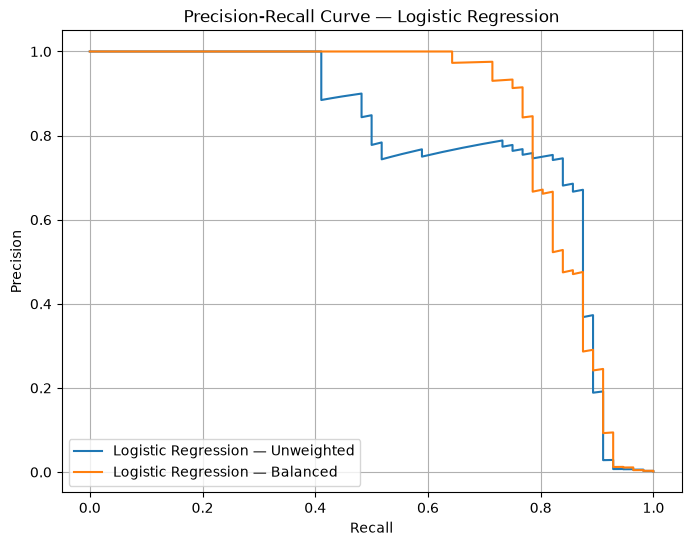

In [12]:
# Import the precision-recall curve utility and plotting library.
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate precision and recall values across thresholds for the unweighted model.
precision_unweighted, recall_unweighted, _ = precision_recall_curve(
    y_val,
    y_val_proba_logistic,
)

# Calculate precision and recall values across thresholds for the balanced model.
precision_balanced, recall_balanced, _ = precision_recall_curve(
    y_val,
    y_val_proba_logistic_balanced,
)

# Create the precision-recall comparison plot.
plt.figure(figsize=(8, 6))

# Plot the unweighted Logistic Regression curve.
plt.plot(
    recall_unweighted,
    precision_unweighted,
    label="Logistic Regression — Unweighted",
)

# Plot the balanced Logistic Regression curve.
plt.plot(
    recall_balanced,
    precision_balanced,
    label="Logistic Regression — Balanced",
)

# Add plot labels and title.
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Logistic Regression")

# Display the model legend and grid.
plt.legend()
plt.grid(True)

# Display the plot.
plt.show()

## 4. Random Forest

Random Forest provides a non-linear tree-based model for comparison with Logistic Regression.

Tree-based models do not require feature scaling, so the original unscaled feature representation is used.

Two configurations are evaluated: an unweighted configuration and a balanced class-weight configuration.

### 4.1 Unweighted Reference

The first Random Forest configuration is unweighted and provides the reference point for the subsequent class-weighted experiment.

The model is trained using the original unscaled training features.

In [13]:
# Import the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# Create the unweighted Random Forest baseline model.
random_forest_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

# Train the model using only the unscaled training data.
random_forest_baseline.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_rf = random_forest_baseline.predict_proba(X_val)[:, 1]

# Confirm that training completed successfully.
print("Random Forest baseline training completed.")
print(f"Validation probability predictions: {len(y_val_proba_rf)}")

Random Forest baseline training completed.
Validation probability predictions: 42721


In [14]:
# Evaluate the unweighted Random Forest model on the validation dataset.
random_forest_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_rf,
)

# Display the validation metrics.
print("Random Forest — Validation Results")
print(f"Average Precision (AP):    {random_forest_results['Average Precision (AP)']:.6f}")
print(f"Precision: {random_forest_results['Precision']:.6f}")
print(f"Recall:    {random_forest_results['Recall']:.6f}")
print(f"F1-score:  {random_forest_results['F1-score']:.6f}")
print(f"ROC-AUC:   {random_forest_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(random_forest_results["Confusion Matrix"])


Random Forest — Validation Results
Average Precision (AP):    0.857966
Precision: 1.000000
Recall:    0.678571
F1-score:  0.808511
ROC-AUC:   0.960912

Confusion Matrix:
[[42665     0]
 [   18    38]]


### 4.2 Balanced Class Weight

The second Random Forest configuration introduces class weighting using the `balanced` strategy.

The model configuration and feature representation remain unchanged from the unweighted Random Forest configuration.

The experimental change is the use of balanced class weights.

In [15]:
# Create a Random Forest model using balanced class weights.
random_forest_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

# Train the balanced Random Forest using only the unscaled training data.
random_forest_balanced.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_rf_balanced = random_forest_balanced.predict_proba(
    X_val
)[:, 1]

# Confirm that training completed successfully.
print("Balanced Random Forest training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_rf_balanced)}"
)

Balanced Random Forest training completed.
Validation probability predictions: 42721


In [16]:
# Evaluate the balanced Random Forest model on the validation dataset.
random_forest_balanced_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_rf_balanced,
)

# Display the validation metrics.
print("Balanced Random Forest — Validation Results")
print(f"Average Precision (AP):    {random_forest_balanced_results['Average Precision (AP)']:.6f}")
print(f"Precision: {random_forest_balanced_results['Precision']:.6f}")
print(f"Recall:    {random_forest_balanced_results['Recall']:.6f}")
print(f"F1-score:  {random_forest_balanced_results['F1-score']:.6f}")
print(f"ROC-AUC:   {random_forest_balanced_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(random_forest_balanced_results["Confusion Matrix"])

Balanced Random Forest — Validation Results
Average Precision (AP):    0.871050
Precision: 1.000000
Recall:    0.714286
F1-score:  0.833333
ROC-AUC:   0.978830

Confusion Matrix:
[[42665     0]
 [   16    40]]


In [17]:
# Import joblib for saving the trained model.
import joblib

# Define the path for the Random Forest model artifact.
random_forest_model_path = "../models/random_forest_baseline.joblib"

# Save the trained Random Forest model to the models directory.
joblib.dump(
    random_forest_baseline,
    random_forest_model_path,
)

# Confirm that the model artifact was saved successfully.
print(f"Random Forest model saved to: {random_forest_model_path}")

Random Forest model saved to: ../models/random_forest_baseline.joblib


## 5. XGBoost

XGBoost provides a gradient boosting model for comparison with the linear and bagging-based approaches.

The original unscaled features are used because tree-based gradient boosting does not require feature scaling.

Two configurations are evaluated: an unweighted configuration and an imbalance-aware configuration using `scale_pos_weight`.

In [18]:
# Import XGBoost to verify that the package is available in the environment.
import xgboost as xgb

# Display the installed XGBoost version.
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.4.1


### 5.1 Unweighted Reference

The first XGBoost configuration is unweighted.

No class weighting or resampling is applied. The purpose is to establish a reference configuration before introducing explicit imbalance handling.

In [19]:
# Import the XGBoost classifier.
from xgboost import XGBClassifier

# Create the unweighted XGBoost baseline model.
xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

# Train the model using only the unscaled training data.
xgb_baseline.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_xgb = xgb_baseline.predict_proba(X_val)[:, 1]

# Confirm that training completed successfully.
print("XGBoost baseline training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_xgb)}"
)

XGBoost baseline training completed.
Validation probability predictions: 42721


In [20]:
# Evaluate the unweighted XGBoost model on the validation dataset.
xgb_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_xgb,
)

# Display the validation metrics.
print("XGBoost — Validation Results")
print(f"Average Precision (AP):    {xgb_results['Average Precision (AP)']:.6f}")
print(f"Precision: {xgb_results['Precision']:.6f}")
print(f"Recall:    {xgb_results['Recall']:.6f}")
print(f"F1-score:  {xgb_results['F1-score']:.6f}")
print(f"ROC-AUC:   {xgb_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(xgb_results["Confusion Matrix"])

XGBoost — Validation Results
Average Precision (AP):    0.828447
Precision: 0.976190
Recall:    0.732143
F1-score:  0.836735
ROC-AUC:   0.978022

Confusion Matrix:
[[42664     1]
 [   15    41]]


### 5.2 Imbalance-Aware Configuration

XGBoost handles class imbalance through model-specific parameters rather than the `class_weight` interface used by several scikit-learn classifiers.

The `scale_pos_weight` parameter is calculated exclusively from the training class distribution.

Only the training data is used to calculate this value.

In [21]:
# Calculate the number of legitimate and fraudulent transactions in the training set.
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

# Calculate the imbalance ratio used for XGBoost's scale_pos_weight parameter.
scale_pos_weight = negative_count / positive_count

# Display the class counts and calculated imbalance ratio.
print(f"Legitimate transactions: {negative_count}")
print(f"Fraudulent transactions: {positive_count}")
print(f"scale_pos_weight: {scale_pos_weight:.6f}")

Legitimate transactions: 198980
Fraudulent transactions: 384
scale_pos_weight: 518.177083


In [22]:
# Create an XGBoost model using the training-derived imbalance weight.
xgb_balanced = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)

# Train the imbalance-aware model using only the unscaled training data.
xgb_balanced.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_xgb_balanced = xgb_balanced.predict_proba(X_val)[:, 1]

# Confirm that training completed successfully.
print("Imbalance-aware XGBoost training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_xgb_balanced)}"
)

Imbalance-aware XGBoost training completed.
Validation probability predictions: 42721


In [23]:
# Evaluate the imbalance-aware XGBoost model on the validation dataset.
xgb_balanced_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_xgb_balanced,
)

# Display the validation metrics.
print("Imbalance-aware XGBoost — Validation Results")
print(f"Average Precision (AP):    {xgb_balanced_results['Average Precision (AP)']:.6f}")
print(f"Precision: {xgb_balanced_results['Precision']:.6f}")
print(f"Recall:    {xgb_balanced_results['Recall']:.6f}")
print(f"F1-score:  {xgb_balanced_results['F1-score']:.6f}")
print(f"ROC-AUC:   {xgb_balanced_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(xgb_balanced_results["Confusion Matrix"])

Imbalance-aware XGBoost — Validation Results
Average Precision (AP):    0.857655
Precision: 0.936170
Recall:    0.785714
F1-score:  0.854369
ROC-AUC:   0.984488

Confusion Matrix:
[[42662     3]
 [   12    44]]


## 6. LightGBM

LightGBM provides a second gradient boosting implementation for comparison with XGBoost.

The experiments below investigate how model complexity and class-imbalance handling affect validation performance.

Because multiple configurations are evaluated on the same validation data, the validation set acts as the **model-selection set** for this notebook. The test set is not used for model selection and remains reserved for final model evaluation; its earlier distribution inspection is disclosed in Section 1.3.

In [24]:
# Import the LightGBM classifier to verify that the package is available.
from lightgbm import LGBMClassifier

# Display the installed LightGBM version.
import lightgbm

print(f"LightGBM version: {lightgbm.__version__}")

LightGBM version: 4.7.0


### 6.1 Initial Unweighted Reference

The initial LightGBM configuration provides an unweighted reference point for the model family.

The model is trained on the original unscaled features.

In [25]:
# Create the unweighted LightGBM baseline model.
lgbm_baseline = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

# Train the LightGBM model using the unscaled training data.
lgbm_baseline.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_lgbm = lgbm_baseline.predict_proba(X_val)[:, 1]

# Confirm that training completed successfully.
print("Unweighted LightGBM training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_lgbm)}"
)

Unweighted LightGBM training completed.
Validation probability predictions: 42721


In [26]:
# Evaluate the unweighted LightGBM model on the validation dataset.
lgbm_baseline_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_lgbm,
)

# Display the validation metrics.
print("Unweighted LightGBM — Validation Results")
print(f"Average Precision (AP):    {lgbm_baseline_results['Average Precision (AP)']:.6f}")
print(f"Precision: {lgbm_baseline_results['Precision']:.6f}")
print(f"Recall:    {lgbm_baseline_results['Recall']:.6f}")
print(f"F1-score:  {lgbm_baseline_results['F1-score']:.6f}")
print(f"ROC-AUC:   {lgbm_baseline_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(lgbm_baseline_results["Confusion Matrix"])

Unweighted LightGBM — Validation Results
Average Precision (AP):    0.027713
Precision: 0.114035
Recall:    0.232143
F1-score:  0.152941
ROC-AUC:   0.614828

Confusion Matrix:
[[42564   101]
 [   43    13]]


### 6.2 Leaf/Depth Diagnostic

The initial configuration caps `max_depth` at 6 and otherwise uses LightGBM's default `num_leaves` of 31. This diagnostic sets `num_leaves=31` explicitly and leaves `max_depth` unset, so the meaningful comparison is the removal of the depth cap rather than a change in leaf count.

In [27]:
# Create an unweighted LightGBM depth diagnostic with 31 leaves and no max_depth cap.
lgbm_baseline_v2 = LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.1,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

# Train the revised LightGBM baseline using the unscaled training data.
lgbm_baseline_v2.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_lgbm_v2 = lgbm_baseline_v2.predict_proba(X_val)[:, 1]

# Confirm that training completed successfully.
print("Revised unweighted LightGBM training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_lgbm_v2)}"
)

Revised unweighted LightGBM training completed.
Validation probability predictions: 42721


In [28]:
# Evaluate the revised unweighted LightGBM model on the validation dataset.
lgbm_baseline_v2_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_lgbm_v2,
)

# Display the validation metrics.
print("Revised Unweighted LightGBM — Validation Results")
print(f"Average Precision (AP):    {lgbm_baseline_v2_results['Average Precision (AP)']:.6f}")
print(f"Precision: {lgbm_baseline_v2_results['Precision']:.6f}")
print(f"Recall:    {lgbm_baseline_v2_results['Recall']:.6f}")
print(f"F1-score:  {lgbm_baseline_v2_results['F1-score']:.6f}")
print(f"ROC-AUC:   {lgbm_baseline_v2_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(lgbm_baseline_v2_results["Confusion Matrix"])

Revised Unweighted LightGBM — Validation Results
Average Precision (AP):    0.045080
Precision: 0.296296
Recall:    0.142857
F1-score:  0.192771
ROC-AUC:   0.571027

Confusion Matrix:
[[42646    19]
 [   48     8]]


### 6.3 Imbalance-Aware Configuration

The imbalance-aware LightGBM configuration uses the training-derived `scale_pos_weight`.

This configuration isolates the effect of explicit class-imbalance handling within LightGBM.

In [29]:
# Create an imbalance-aware LightGBM model using the training-derived class weight.
lgbm_balanced = LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.1,
    colsample_bytree=0.8,
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

# Train the imbalance-aware LightGBM model using the unscaled training data.
lgbm_balanced.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_lgbm_balanced = lgbm_balanced.predict_proba(X_val)[:, 1]

# Confirm that training completed successfully.
print("Imbalance-aware LightGBM training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_lgbm_balanced)}"
)

Imbalance-aware LightGBM training completed.
Validation probability predictions: 42721


In [30]:
# Evaluate the imbalance-aware LightGBM model on the validation dataset.
lgbm_balanced_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_lgbm_balanced,
)

# Display the validation metrics.
print("Imbalance-aware LightGBM — Validation Results")
print(f"Average Precision (AP):    {lgbm_balanced_results['Average Precision (AP)']:.6f}")
print(f"Precision: {lgbm_balanced_results['Precision']:.6f}")
print(f"Recall:    {lgbm_balanced_results['Recall']:.6f}")
print(f"F1-score:  {lgbm_balanced_results['F1-score']:.6f}")
print(f"ROC-AUC:   {lgbm_balanced_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(lgbm_balanced_results["Confusion Matrix"])

Imbalance-aware LightGBM — Validation Results
Average Precision (AP):    0.078461
Precision: 0.087719
Recall:    0.892857
F1-score:  0.159744
ROC-AUC:   0.940331

Confusion Matrix:
[[42145   520]
 [    6    50]]


### 6.4 Regularized Unweighted Configuration

This unweighted configuration adds `min_child_samples=100` to control leaf formation. It is retained as the validation-selected LightGBM reference candidate because it provides the unweighted partner for the regularized class-weight diagnostic. It is not a final model; the same validation set is used to compare configurations.

In [31]:
# Create a more conservative unweighted LightGBM model.
lgbm_regularized = LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.1,
    min_child_samples=100,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

# Train the regularized LightGBM model using the unscaled training data.
lgbm_regularized.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_lgbm_regularized = (
    lgbm_regularized.predict_proba(X_val)[:, 1]
)

# Confirm that training completed successfully.
print("Regularized unweighted LightGBM training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_lgbm_regularized)}"
)

Regularized unweighted LightGBM training completed.
Validation probability predictions: 42721


In [32]:
# Evaluate the regularized unweighted LightGBM model on the validation dataset.
lgbm_regularized_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_lgbm_regularized,
)

# Display the validation metrics.
print("Regularized Unweighted LightGBM — Validation Results")
print(f"Average Precision (AP):    {lgbm_regularized_results['Average Precision (AP)']:.6f}")
print(f"Precision: {lgbm_regularized_results['Precision']:.6f}")
print(f"Recall:    {lgbm_regularized_results['Recall']:.6f}")
print(f"F1-score:  {lgbm_regularized_results['F1-score']:.6f}")
print(f"ROC-AUC:   {lgbm_regularized_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(lgbm_regularized_results["Confusion Matrix"])

Regularized Unweighted LightGBM — Validation Results
Average Precision (AP):    0.681356
Precision: 0.944444
Recall:    0.607143
F1-score:  0.739130
ROC-AUC:   0.876734

Confusion Matrix:
[[42663     2]
 [   22    34]]


### 6.5 Regularized Imbalance-Aware Configuration

This configuration combines the regularized LightGBM structure with the training-derived `scale_pos_weight`.

It is evaluated to determine whether explicit imbalance handling remains useful after regularising model complexity.

In [33]:
# Create an imbalance-aware LightGBM model using the regularized configuration.
lgbm_regularized_balanced = LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.1,
    min_child_samples=100,
    colsample_bytree=0.8,
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

# Train the imbalance-aware regularized LightGBM model.
lgbm_regularized_balanced.fit(X_train, y_train)

# Generate fraud probabilities for the validation dataset.
y_val_proba_lgbm_regularized_balanced = (
    lgbm_regularized_balanced.predict_proba(X_val)[:, 1]
)

# Confirm that training completed successfully.
print("Regularized imbalance-aware LightGBM training completed.")
print(
    f"Validation probability predictions: "
    f"{len(y_val_proba_lgbm_regularized_balanced)}"
)

Regularized imbalance-aware LightGBM training completed.
Validation probability predictions: 42721


In [34]:
# Evaluate the regularized imbalance-aware LightGBM model on the validation dataset.
lgbm_regularized_balanced_results = evaluate_model(
    y_true=y_val,
    y_pred_proba=y_val_proba_lgbm_regularized_balanced,
)

# Display the validation metrics.
print("Regularized Imbalance-aware LightGBM — Validation Results")
print(f"Average Precision (AP):    {lgbm_regularized_balanced_results['Average Precision (AP)']:.6f}")
print(f"Precision: {lgbm_regularized_balanced_results['Precision']:.6f}")
print(f"Recall:    {lgbm_regularized_balanced_results['Recall']:.6f}")
print(f"F1-score:  {lgbm_regularized_balanced_results['F1-score']:.6f}")
print(f"ROC-AUC:   {lgbm_regularized_balanced_results['ROC-AUC']:.6f}")

# Display the confusion matrix at the default probability threshold of 0.5.
print("\nConfusion Matrix:")
print(
    lgbm_regularized_balanced_results["Confusion Matrix"]
)

Regularized Imbalance-aware LightGBM — Validation Results
Average Precision (AP):    0.026186
Precision: 0.031593
Recall:    0.821429
F1-score:  0.060847
ROC-AUC:   0.894186

Confusion Matrix:
[[41255  1410]
 [   10    46]]


## 7. Tier 1 Comparison and Interpretation

### 7.1 Primary Reference Comparison

In [35]:
# Primary reference comparison: one predefined reference per model family.
primary_reference_rows = [
    ("Logistic Regression", "Unweighted", logistic_validation_results),
    ("Random Forest", "Unweighted", random_forest_results),
    ("XGBoost", "Unweighted", xgb_results),
    ("LightGBM", "Regularized unweighted (validation-selected candidate)", lgbm_regularized_results),
]

baseline_results = pd.DataFrame(
    [
        {
            "Model": model_name,
            "Reference configuration": configuration,
            "Average Precision (AP)": result["Average Precision (AP)"],
            "Precision @ 0.5": result["Precision"],
            "Recall @ 0.5": result["Recall"],
            "F1-score @ 0.5": result["F1-score"],
            "ROC-AUC": result["ROC-AUC"],
        }
        for model_name, configuration, result in primary_reference_rows
    ]
)

baseline_results.sort_values(
    "Average Precision (AP)", ascending=False
).style.format({
    "Average Precision (AP)": "{:.4f}",
    "Precision @ 0.5": "{:.4f}",
    "Recall @ 0.5": "{:.4f}",
    "F1-score @ 0.5": "{:.4f}",
    "ROC-AUC": "{:.4f}",
})

,Model,Reference configuration,Average Precision (AP),Precision @ 0.5,Recall @ 0.5,F1-score @ 0.5,ROC-AUC
1,Random Forest,Unweighted,0.8580,1.0000,0.6786,0.8085,0.9609
2,XGBoost,Unweighted,0.8284,0.9762,0.7321,0.8367,0.9780
0,Logistic Regression,Unweighted,0.7849,0.7500,0.5357,0.6250,0.9800
3,LightGBM,Regularized unweighted (validation-selected candidate),0.6814,0.9444,0.6071,0.7391,0.8767


In [ ]:
# Persist the established Tier 1 reference metrics for downstream notebooks.
import json

tier1_validation_results = {
    model_name: {
        "AP": round(float(result["Average Precision (AP)"]), 4),
        "Precision@0.5": round(float(result["Precision"]), 4),
        "Recall@0.5": round(float(result["Recall"]), 4),
        "F1@0.5": round(float(result["F1-score"]), 4),
        "ROC-AUC": round(float(result["ROC-AUC"]), 4),
    }
    for model_name, _, result in primary_reference_rows
}

REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
TIER1_RESULTS_PATH = REPORTS_DIR / "tier1_validation_results.json"
with TIER1_RESULTS_PATH.open("w", encoding="utf-8") as results_file:
    json.dump(tier1_validation_results, results_file, indent=4)
    results_file.write("\n")

print(f"Tier 1 validation results saved to: {TIER1_RESULTS_PATH}")


### 7.2 Configuration Diagnostics

In [36]:
# Keep class-weight and complexity experiments separate from the primary references.
diagnostic_rows = [
    ("Logistic Regression", "Balanced class weight", logistic_balanced_results),
    ("Random Forest", "Balanced class weight", random_forest_balanced_results),
    ("XGBoost", "Imbalance-aware", xgb_balanced_results),
    ("LightGBM", "Initial unweighted, depth-capped", lgbm_baseline_results),
    ("LightGBM", "No depth cap, 31 leaves", lgbm_baseline_v2_results),
    ("LightGBM", "Imbalance-aware", lgbm_balanced_results),
    ("LightGBM", "Regularized imbalance-aware", lgbm_regularized_balanced_results),
]

diagnostic_results = pd.DataFrame(
    [
        {
            "Model": model_name,
            "Diagnostic configuration": configuration,
            "Average Precision (AP)": result["Average Precision (AP)"],
            "Precision @ 0.5": result["Precision"],
            "Recall @ 0.5": result["Recall"],
            "F1-score @ 0.5": result["F1-score"],
            "ROC-AUC": result["ROC-AUC"],
        }
        for model_name, configuration, result in diagnostic_rows
    ]
)

diagnostic_results.sort_values(
    "Average Precision (AP)", ascending=False
).style.format({
    "Average Precision (AP)": "{:.4f}",
    "Precision @ 0.5": "{:.4f}",
    "Recall @ 0.5": "{:.4f}",
    "F1-score @ 0.5": "{:.4f}",
    "ROC-AUC": "{:.4f}",
})

,Model,Diagnostic configuration,Average Precision (AP),Precision @ 0.5,Recall @ 0.5,F1-score @ 0.5,ROC-AUC
1,Random Forest,Balanced class weight,0.8710,1.0000,0.7143,0.8333,0.9788
2,XGBoost,Imbalance-aware,0.8577,0.9362,0.7857,0.8544,0.9845
0,Logistic Regression,Balanced class weight,0.8394,0.0537,0.9286,0.1015,0.9829
5,LightGBM,Imbalance-aware,0.0785,0.0877,0.8929,0.1597,0.9403
4,LightGBM,"No depth cap, 31 leaves",0.0451,0.2963,0.1429,0.1928,0.5710
3,LightGBM,"Initial unweighted, depth-capped",0.0277,0.1140,0.2321,0.1529,0.6148
6,LightGBM,Regularized imbalance-aware,0.0262,0.0316,0.8214,0.0608,0.8942


### 7.3 Validation Limitations and Next Evaluation Step

The Tier 1 experiments evaluated four machine learning algorithms:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

The experiments also investigated different approaches to class imbalance, including class weighting and `scale_pos_weight`.

The validation results show that class imbalance has a substantial impact on model behaviour. Strategies that increase fraud detection recall can also produce a large increase in false positives. Therefore, accuracy or recall alone would not provide an adequate basis for comparing the models.

Average Precision (AP) is used as the primary evaluation metric because the dataset is highly imbalanced, with fraud representing only a small fraction of all transactions. Precision, Recall, F1-score, ROC-AUC, and the confusion matrix are used as complementary metrics.

The experiments also showed that model behaviour can be sensitive to both class-imbalance handling and model complexity. In particular, some imbalance-aware LightGBM configurations produced substantially higher recall but much lower precision and Average Precision (AP).

The validation set was used as the model-selection set throughout these experiments. Because multiple configurations were evaluated on the same validation data, the validation results should not be interpreted as an unbiased estimate of final generalisation performance.

This notebook establishes Tier 1 reference configurations; the final project model is selected after comparing validation results across tiers. The regularized unweighted LightGBM configuration is a validation-selected candidate within its family, not the final project selection. These experiments are not a systematic hyperparameter search. The threshold of 0.5 is descriptive, and test data is not used for model selection.

The next phase will investigate deep learning approaches for tabular fraud detection, beginning with an MLP and an Autoencoder.